In [1]:
from QiskitTranspiler.transpiler.passes.layout.layout import Layout
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator

Distance matrix:
 [[0, 1, 1, 1], [1, 0, 2, 2], [1, 2, 0, 2], [1, 2, 2, 0]]
Performing swap: (2, 0) to resolve dependency: g1
-----------------------------------------------------------

Performing swap: (3, 2) to resolve dependency: g3
-----------------------------------------------------------

Performing swap: (0, 3) to resolve dependency: g4
-----------------------------------------------------------

Nodeid: g0
Nodeid: o0
Nodeid: g1
Nodeid: g2
Nodeid: o1
Nodeid: o4
Nodeid: g3
Nodeid: o2
Nodeid: o6
Nodeid: g4
Nodeid: o3
Nodeid: o5


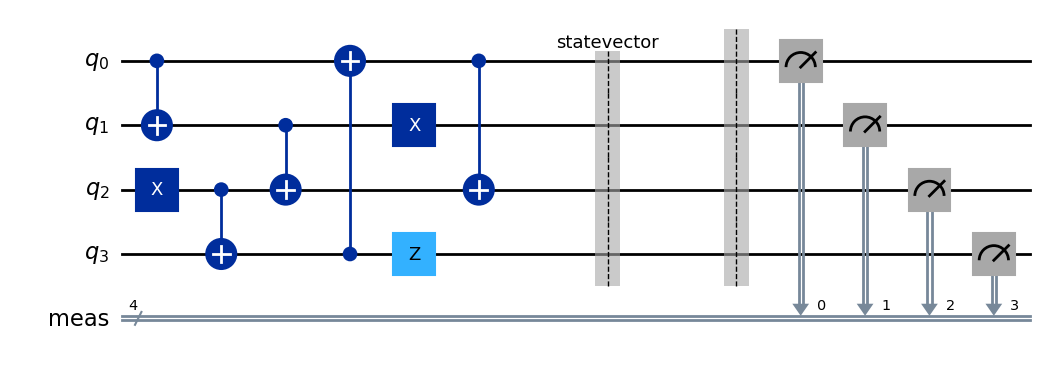

In [2]:
qc = QuantumCircuit(4)
qc.cx(0,1)
qc.x(2)
qc.cx(2,3)
qc.cx(1,2)
qc.x(1)
qc.cx(3,0)
qc.z(3)
qc.cx(0,2)

qc.save_statevector()

qc.measure_all()

# 2D grid topology (3x3)
# Qubits arranged as:
#  0 - 1 - 2
#  |   |   |
#  3 - 4 - 5
#  |   |   |
#  6 - 7 - 8

complex_coupling = [
    # Horizontal edges
    [0, 1], [1, 2],
    [3, 4], [4, 5],
    [6, 7], [7, 8],
    # Vertical edges
    [0, 3], [3, 6],
    [1, 4], [4, 7],
    [2, 5], [5, 8],
]

backend_complex = GenericBackendV2(
    num_qubits=9,
    basis_gates=["x", "sx", "rz", "cx"],
    coupling_map=complex_coupling,
    seed=123
)

sim = AerSimulator()

qc_layout, mapping = Layout.run_layout(qc, backend_complex)

qc.draw("mpl")

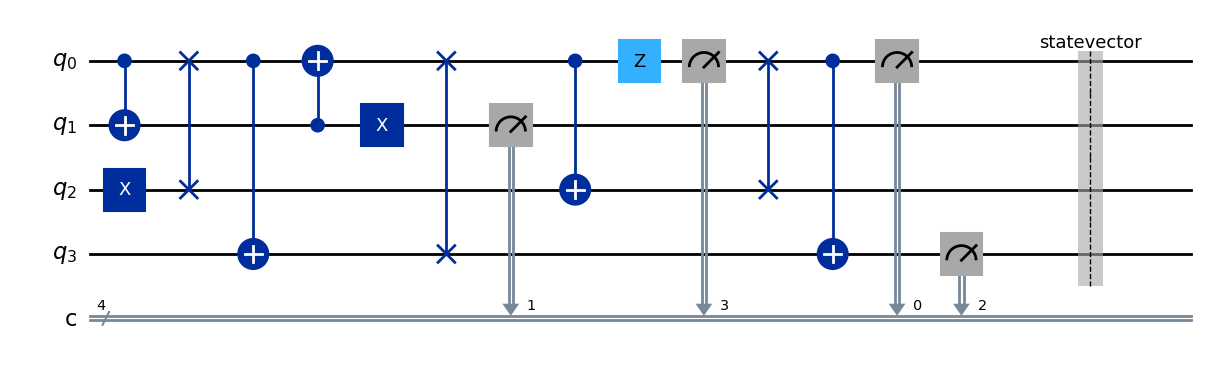

In [3]:
qc_layout.save_statevector()
qc_layout.draw("mpl")

In [4]:
result = sim.run(qc).result()
sv_original = result.get_statevector()
print("Original statevector:", sv_original)

Original statevector: Statevector([ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
              0.+0.j, -0.+0.j, -0.+0.j, -0.+0.j, -1.+0.j, -0.+0.j, -0.+0.j,
             -0.+0.j, -0.+0.j],
            dims=(2, 2, 2, 2))


In [5]:
from qiskit.quantum_info import Statevector
sv = Statevector(sv_original)
sv.draw('latex')

<IPython.core.display.Latex object>

In [7]:
result_layout = sim.run(qc_layout).result()
sv_layout = result_layout.get_statevector()

sv_layout = Statevector(sv_layout)
sv_layout.draw('latex')

<IPython.core.display.Latex object>